In [44]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
import pandas as pd

data = pd.read_csv("../loan_prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


C:\Users\HP\AppData\Local\Temp\ipykernel_18712\2623299727.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['ApplicantIncome'], color='r')
C:\Users\HP\AppData\Local\Temp\ipykernel_18712\2623299727.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Credit_History'])


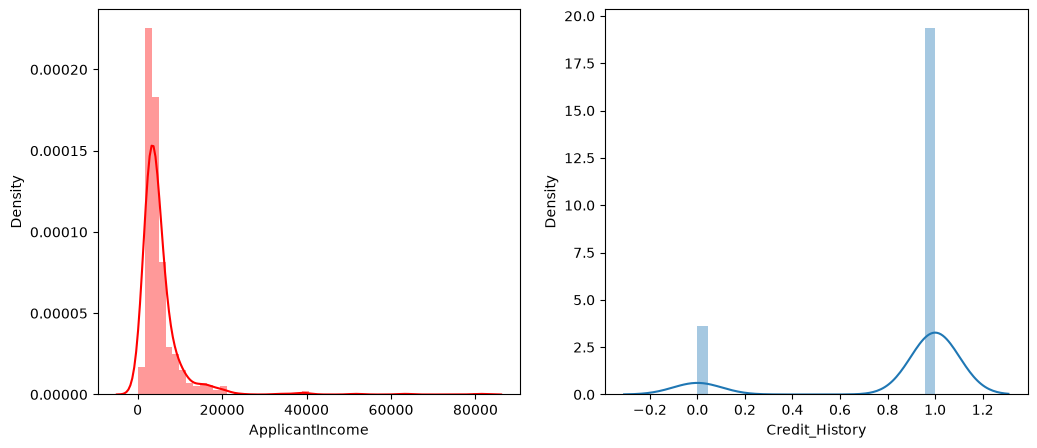

In [46]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.distplot(data['ApplicantIncome'], color='r')

plt.subplot(122)
sns.distplot(data['Credit_History'])

plt.show()

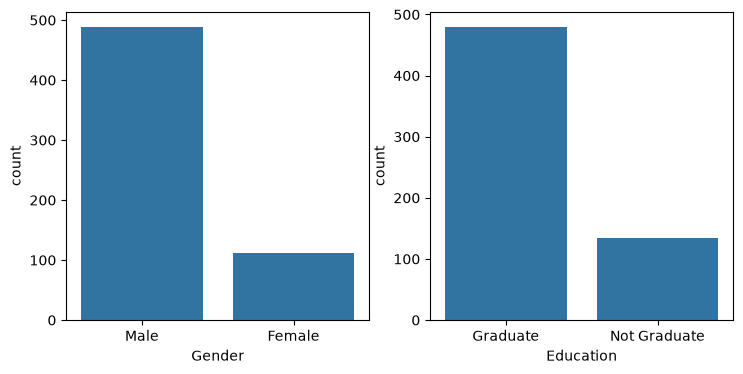

In [47]:
plt.figure(figsize=(18,4))

plt.subplot(1,4,1)
sns.countplot(data=data, x='Gender')

plt.subplot(1,4,2)
sns.countplot(data=data, x='Education')

plt.show()

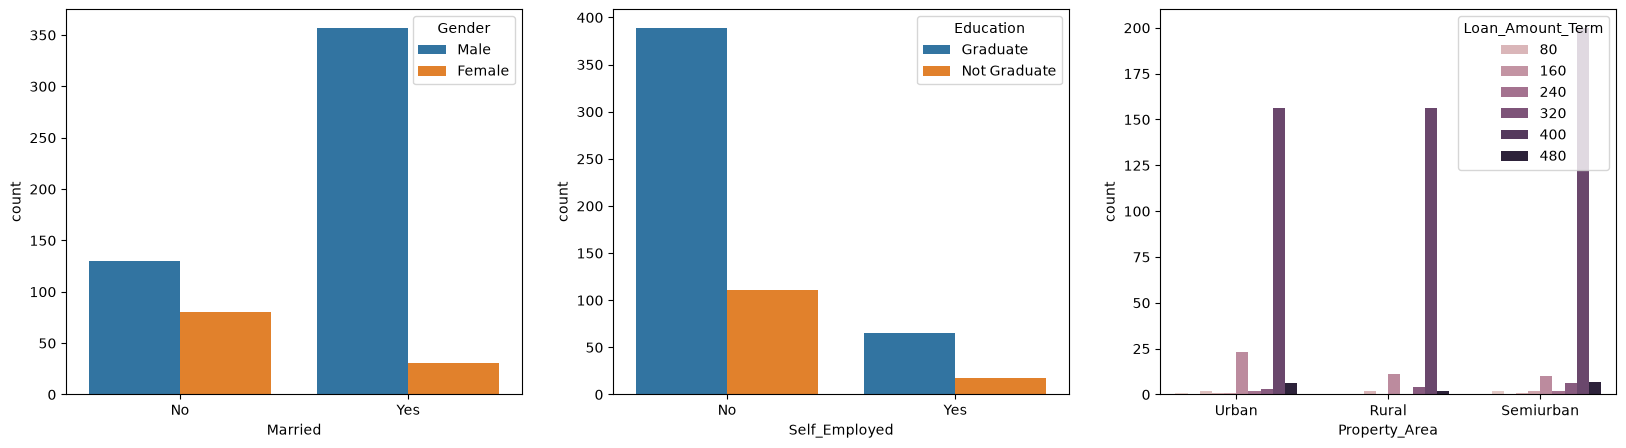

In [48]:
# Bivariate Analysis

plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(data=data, x='Married', hue='Gender')

plt.subplot(132)
sns.countplot(data=data, x='Self_Employed', hue='Education')

plt.subplot(133)
sns.countplot(data=data, x='Property_Area', hue='Loan_Amount_Term')

plt.show()

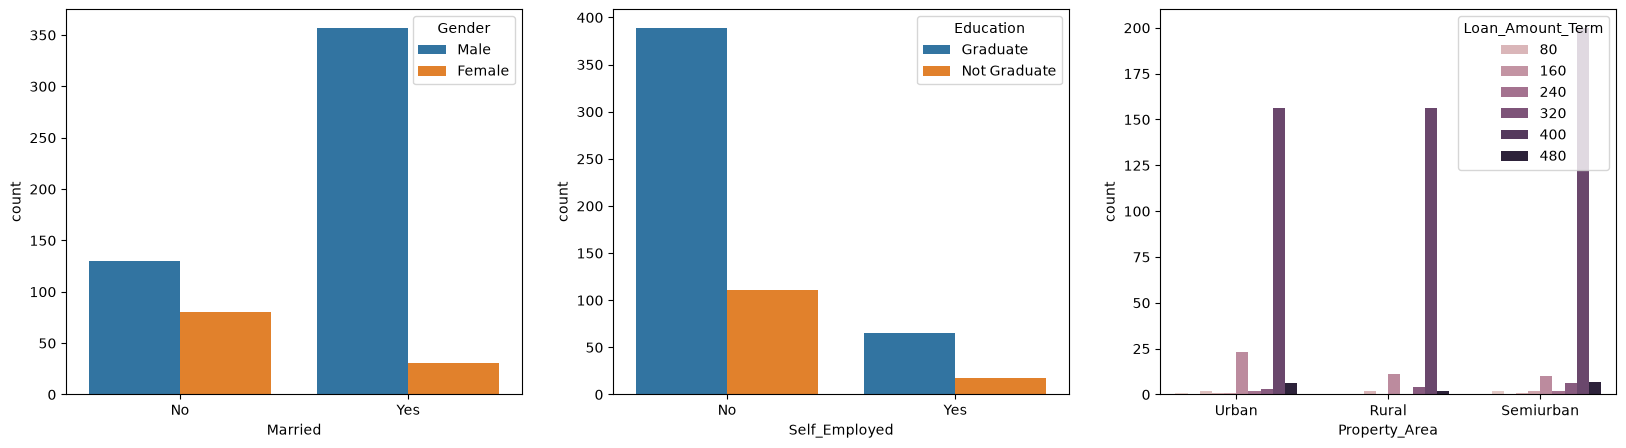

In [49]:
# Bivariate Analysis

plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(data=data, x='Married', hue='Gender')

plt.subplot(132)
sns.countplot(data=data, x='Self_Employed', hue='Education')

plt.subplot(133)
sns.countplot(data=data, x='Property_Area', hue='Loan_Amount_Term')

plt.show()

In [50]:
data['Gender'] = data['Gender'].map({'Female':1,'Male':0})
data['Married'] = data['Married'].map({'Yes':1,'No':0})
data['Education'] = data['Education'].map({'Graduate':1,'Not Graduate':0})
data['Property_Area'] = data['Property_Area'].map({'Urban':2,'Semiurban':1,'Rural':0})
data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1,No,5849,0.0,NaN,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1,No,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1,Yes,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,0,No,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1,No,6000,0.0,141.0,360.0,1.0,2,1


In [51]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mean())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mean())
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

In [52]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [53]:
data['Dependents'] = data['Dependents'].str.replace('+', '', regex=False)

In [54]:
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

In [55]:
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

In [56]:
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode()[0])

In [57]:
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])

In [58]:
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

In [59]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [60]:
data['Self_Employed'] = data['Self_Employed'].map({'Yes':1, 'No':0})
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

In [61]:
data['Self_Employed'] = data['Self_Employed'].astype('int64')

In [62]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0,1,0,5849,0.0,146.412162,360.0,1.0,2,1
1,LP001003,0.0,1.0,1,1,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,LP001005,0.0,1.0,0,1,1,3000,0.0,66.000000,360.0,1.0,2,1
3,LP001006,0.0,1.0,0,0,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,LP001008,0.0,0.0,0,1,0,6000,0.0,141.000000,360.0,1.0,2,1


In [63]:
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Gender'] = le.fit_transform(data['Gender'])
data['Married'] = le.fit_transform(data['Married'])
data['Education'] = le.fit_transform(data['Education'])
data['Self_Employed'] = le.fit_transform(data['Self_Employed'])
data['Property_Area'] = le.fit_transform(data['Property_Area'])
data['Loan_Status'] = le.fit_transform(data['Loan_Status'])

data['Dependents'] = data['Dependents'].replace('3+', '3')
data['Dependents'] = data['Dependents'].astype(int)

In [65]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 62.5 KB


In [66]:
x = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

In [67]:
print(x.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [68]:
# Fill numeric columns with median
x['LoanAmount'] = x['LoanAmount'].fillna(x['LoanAmount'].median())
x['Loan_Amount_Term'] = x['Loan_Amount_Term'].fillna(x['Loan_Amount_Term'].median())
x['Credit_History'] = x['Credit_History'].fillna(x['Credit_History'].median())

In [69]:
x['Gender'] = x['Gender'].fillna(x['Gender'].mode()[0])
x['Married'] = x['Married'].fillna(x['Married'].mode()[0])
x['Dependents'] = x['Dependents'].fillna(x['Dependents'].mode()[0])
x['Self_Employed'] = x['Self_Employed'].fillna(x['Self_Employed'].mode()[0])

In [70]:
print(x.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_bal, y_bal = smote.fit_resample(x, y)

print(x_bal.shape)
print(y_bal.shape)

(844, 11)
(844,)


In [72]:
from sklearn.preprocessing import StandardScaler

names = x.columns

sc = StandardScaler()

x_bal = sc.fit_transform(x_bal)

x_bal = pd.DataFrame(x_bal, columns=names)

x_bal.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,-0.411066,-1.162314,-0.686821,0.630358,-0.339009,0.111762,-0.584610,0.011462,0.295282,0.574053,1.359312
1,-0.411066,0.860352,0.374858,0.630358,-0.339009,-0.118995,-0.024552,-0.217914,0.295282,0.574053,-1.201535
2,-0.411066,0.860352,-0.686821,0.630358,2.949771,-0.407532,-0.584610,-0.990302,0.295282,0.574053,1.359312
3,-0.411066,0.860352,-0.686821,-1.586401,-0.339009,-0.483539,0.291131,-0.317577,0.295282,0.574053,1.359312
4,-0.411066,-1.162314,-0.686821,0.630358,-0.339009,0.139285,-0.584610,-0.055962,0.295282,0.574053,1.359312


In [73]:
from sklearn.model_selection import train_test_split

In [74]:
x_train, x_test, y_train, y_test = train_test_split(
    x_bal,
    y_bal,
    test_size=0.2,
    random_state=42
)

In [75]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(675, 11)
(169, 11)
(675,)
(169,)


In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def RandomForest(x_train, x_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)

    model.fit(x_train, y_train)

    y_tr = model.predict(x_train)
    print("Train Accuracy:", accuracy_score(y_train, y_tr))

    yPred = model.predict(x_test)
    print("Test Accuracy:", accuracy_score(y_test, yPred))

    print(confusion_matrix(y_test, yPred))
    print(classification_report(y_test, yPred))

    return model

In [78]:
model = RandomForest(x_train, x_test, y_train, y_test)

Train Accuracy: 1.0
Test Accuracy: 0.8106508875739645
[[70 24]
 [ 8 67]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81        94
           1       0.74      0.89      0.81        75

    accuracy                           0.81       169
   macro avg       0.82      0.82      0.81       169
weighted avg       0.83      0.81      0.81       169



In [79]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [80]:
def KNN(X_train, X_test, y_train, y_test):

    model = KNeighborsClassifier()

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_train, y_tr))

    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, yPred))

    print(confusion_matrix(y_test, yPred))
    print(classification_report(y_test, yPred))

In [81]:
KNN(x_train, x_test, y_train, y_test)

Train Accuracy: 0.8311111111111111
Test Accuracy: 0.6863905325443787
[[56 38]
 [15 60]]
              precision    recall  f1-score   support

           0       0.79      0.60      0.68        94
           1       0.61      0.80      0.69        75

    accuracy                           0.69       169
   macro avg       0.70      0.70      0.69       169
weighted avg       0.71      0.69      0.69       169



In [82]:
from sklearn.ensemble import GradientBoostingClassifier

In [83]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def XGB(x_train, x_test, y_train, y_test):

    model = GradientBoostingClassifier(random_state=42)

    model.fit(x_train, y_train)

    y_tr = model.predict(x_train)
    print("Train Accuracy:", accuracy_score(y_train, y_tr))

    yPred = model.predict(x_test)
    print("Test Accuracy:", accuracy_score(y_test, yPred))

    print(confusion_matrix(y_test, yPred))
    print(classification_report(y_test, yPred))

    return model

In [84]:
model = XGB(x_train, x_test, y_train, y_test)

Train Accuracy: 0.9125925925925926
Test Accuracy: 0.7988165680473372
[[66 28]
 [ 6 69]]
              precision    recall  f1-score   support

           0       0.92      0.70      0.80        94
           1       0.71      0.92      0.80        75

    accuracy                           0.80       169
   macro avg       0.81      0.81      0.80       169
weighted avg       0.83      0.80      0.80       169



In [85]:
import pickle

In [86]:
model = XGB(x_train, x_test, y_train, y_test)

Train Accuracy: 0.9125925925925926
Test Accuracy: 0.7988165680473372
[[66 28]
 [ 6 69]]
              precision    recall  f1-score   support

           0       0.92      0.70      0.80        94
           1       0.71      0.92      0.80        75

    accuracy                           0.80       169
   macro avg       0.81      0.81      0.80       169
weighted avg       0.83      0.80      0.80       169



In [87]:
pickle.dump(model, open("rdf.pkl", "wb"))

In [88]:
import pickle

pickle.dump(model, open("rdf.pkl", "wb"))
pickle.dump(sc, open("scale1.pkl", "wb"))